<a href="https://colab.research.google.com/github/taemakafrktare-pixel/korea-visitors-covid19/blob/main/Interactive_Visualization_of_Visitors_to_South_Korea_Before_and_After_COVID_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interactive Visualization of Visitors to South Korea Before and After COVID-19
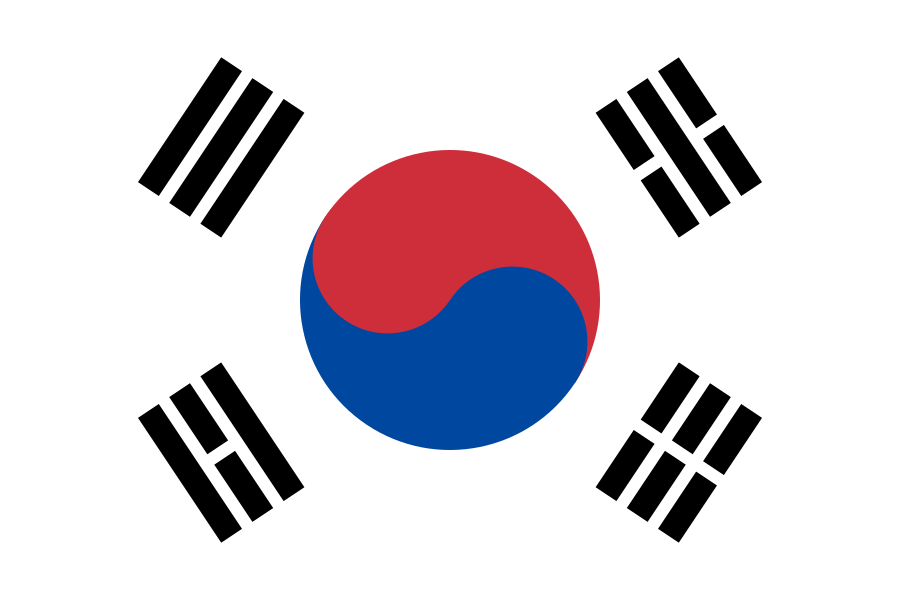
*Flag of South Korea. Source: Wikimedia Commons (public domain).*
## Overview
This project shows how the number of visitors to South Korea has changed over recent years. It looks at how the COVID-19 period affected tourism in South Korea, and how tourism recovered afterwards.

## Why I chose this topic
I chose this topic because it shows how high tourism numbers were before COVID-19, how sharply they fell during the pandemic, and how visitor numbers rose again during the recovery. As someone who hopes to study and work in South Korea in the future, I wanted to explore how the COVID-19 downturn and the recovery that followed affected tourism, which is an important part of the country's economy.

## Data Source
Monthly visitor numbers (January 2019 to December 2024) come from the Tourism Knowledge & Information System (know.tour.go.kr), the official tourism statistics website of South Korea. The monthly totals add up exactly to the yearly totals published by the Korea Tourism Organization (KTO).
## Tools
- Python
- pandas, to read and organize the data
- plotly, to build the interactive charts
- Google Colab, to run the project

In [ ]:
#@title Load the data
from google.colab import output
output.enable_custom_widget_manager()
import pandas as pd
import plotly.graph_objects as go

data = {
    2019: [1104803, 1201802, 1535641, 1635066, 1485684, 1476218, 1448067, 1586299, 1459664, 1656195, 1456429, 1456888],
    2020: [1272708, 685212, 83497, 29415, 30806, 36938, 61012, 68797, 65040, 61585, 61764, 62344],
    2021: [58397, 65582, 74604, 70112, 74463, 77029, 83005, 97087, 89800, 92416, 94358, 90150],
    2022: [81851, 99999, 96768, 127919, 175922, 227713, 263986, 310945, 337638, 476097, 459906, 539273],
    2023: [434429, 479248, 800575, 888776, 867130, 960638, 1032188, 1089133, 1098034, 1229899, 1114990, 1036625],
    2024: [880881, 1030244, 1491748, 1462797, 1418463, 1417274, 1408499, 1563221, 1464300, 1600263, 1361076, 1270863],
}
df = pd.DataFrame([(y, m + 1, v) for y, vals in data.items() for m, v in enumerate(vals)],
                  columns=["year", "month", "visitors"])
df.head()

,year,month,visitors
0,2019,1,1104803
1,2019,2,1201802
2,2019,3,1535641
3,2019,4,1635066
4,2019,5,1485684


In [ ]:
#@title Total visitors per year
import ipywidgets as widgets

annual = {2019: 17502756, 2020: 2519118, 2021: 967003,
          2022: 3198017, 2023: 11031665, 2024: 16369629}

years = sorted(set(annual) | set(df.year))

def total(y):
    m = df[df.year == y]
    return m.visitors.sum() if len(m) else annual[y]

fig = go.Figure(go.Scatter(x=[str(y) for y in years],
                           y=[total(y) for y in years],
                           mode="lines+markers", marker_size=10))
fig.update_layout(title="Total visitors per year",
                  xaxis_title="Year", yaxis_title="Visitors")
fig.show()

def show_months(year):
    m = df[df.year == year].sort_values("month")
    if m.empty:
        print(f"No monthly data for {year} yet.")
        return
    f = go.Figure(go.Bar(x=m.month, y=m.visitors))
    f.update_layout(title=f"Monthly visitors in {year}",
                    xaxis_title="Month", yaxis_title="Visitors")
    f.show()

widgets.interact(show_months, year=years);

interactive(children=(Dropdown(description='year', options=(2019, 2020, 2021, 2022, 2023, 2024), value=2019), …

In [ ]:
#@title Monthly visitors, all years
fig_all = go.Figure()
for y in sorted(df.year.unique()):
    m = df[df.year == y].sort_values("month")
    fig_all.add_trace(go.Scatter(x=m.month, y=m.visitors,
                                 mode="lines+markers", name=str(y)))

fig_all.update_layout(title="Monthly visitors, all years (2019-2024)",
                      xaxis_title="Month", yaxis_title="Visitors",
                      xaxis=dict(tickmode="linear", dtick=1))
fig_all.show()

## Charts preview
These are screenshots of the three charts in this project.

**Total visitors per year**
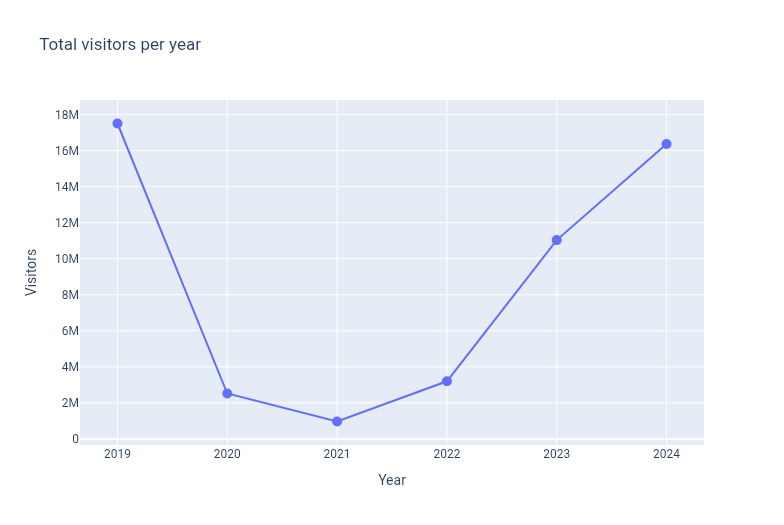

**Monthly visitors in 2019**
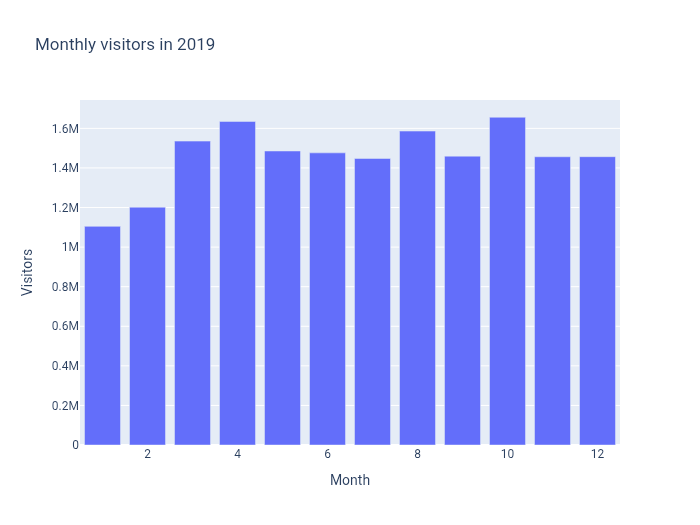

**Monthly visitors, all years (2019-2024)**
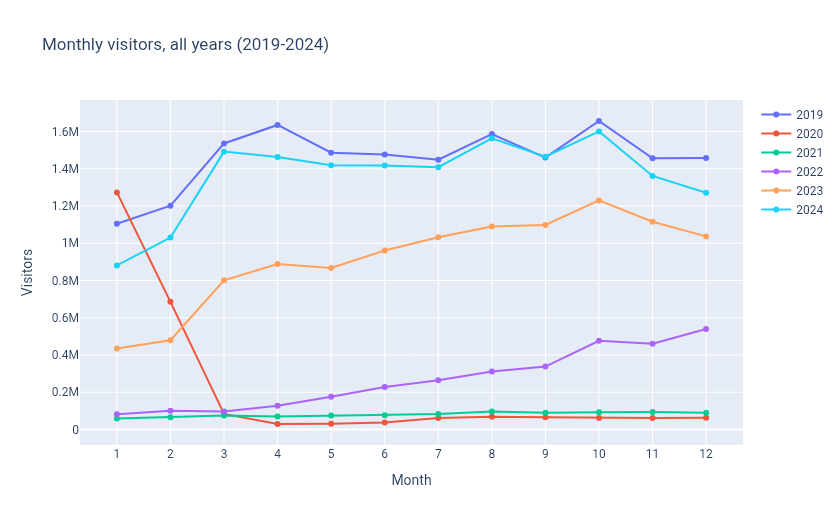

This chart shows the monthly visitors for each year, so the years can be compared month by month. In 2020, the number started high in January, close to 2019, but then dropped very quickly between February and March. This shows when COVID-19 started to affect tourism. In 2020 and 2021, the lines stay almost flat and very close to zero for the whole year. In 2022 and 2023, the numbers rise slowly during the year. In 2024, the line is very close to the line for 2019 in most months.

## Key Findings
In 2019, a large number of tourists visited South Korea from all over the world. The total was 17.5 million visitors. In 2020, the number dropped sharply because of the COVID-19 pandemic, to 2.5 million visitors. It kept falling and reached 967 thousand visitors in 2021. During the recovery, the number rose again to 3.2 million in 2022, then to 11 million in 2023, and to 16.4 million in 2024. The highest number of visitors in these six years was recorded in 2019.

## What I learned
Through this project, I learned many things. The most important one was reading a CSV file and organizing data with libraries like pandas. I also learned how to draw charts and give the user more precise options, so that when someone wants to look at one specific year, they can choose it. I also learned how to find official statistics published by the government. I faced many problems and difficulties, such as mistakes in writing the code and choosing websites that were not official to rely on their data.

## Next steps
In the future, I would like to add more years to this data. I would also like to look at the visitors by country, to see which countries sent the most tourists to South Korea.